### Connect to Github, Google Drive, Kaggle
When you connect to external services like Github, Google Drive, or Kaggle, you can easily access and manage your files, datasets, and repositories directly from your development environment. This integration allows for seamless collaboration, version control, and data management.

When asked, you have to provide an active token to connect to Github.

In [ ]:
import os, sys, subprocess
from getpass import getpass

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "real-video"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")     # Digit your Github token and press enter.
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KEY"

## **Download DATASET**

At this point, you will downlaod the dataset from Kaggle.

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [03:20<00:00, 34.9MB/s]

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


For later use, install yt-dlp, which is a feature-rich command-line audio/video downloader.

In [4]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.9 MB/s eta 0:00:00:00:01


Import all necessary libraries and modules for the project. This includes standard libraries, third-party packages, and custom modules that are required for the implementation of the Unified Lifelong Action Learning (ULAL) framework. Initialize the framework by setting up configurations, paths, and any other necessary parameters. Inizialize the random seed for reproducibility of results across different runs of the code.

In [ ]:
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
Classes   : base=10 task1=5 task2=5


42

## **Setup (30 classes)**

__cfg.SELECTED_CLASSES__ contains the base classes used for training the model. For every new task, select other 10 different classes from the remaining 70 classes. The model will be trained on these new classes while retaining knowledge of the previously learned classes.

In [6]:
cfg.TASK_1 = ["ApplyEyeMakeup", "ApplyLipstick", "Archery", "BabyCrawling", "BalanceBeam",
              "BandMarching", "BlowDryHair", "BlowingCandles", "BodyWeightSquats", "Bowling"]
cfg.TASK_2 = ["BoxingPunchingBag", "BoxingSpeedBag", "BrushingTeeth", "CliffDiving", "CricketBowling",
              "CricketShot", "CuttingInKitchen", "FieldHockeyPenalty", "Haircut", "SoccerPenalty"]

**ALL_CLASSES_LIST** contains all the classes used.

In [7]:
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx     = {name: i for i, name in enumerate(ALL_CLASSES_LIST)}
n_base = len(cfg.SELECTED_CLASSES)   # 10 base
n_t1   = len(cfg.TASK_1)             # 10 new in task 1
n_t2   = len(cfg.TASK_2)             # 10 new in task 2
print(f"base {n_base}  task1 {n_t1}  task2 {n_t2}  total {len(ALL_CLASSES_LIST)}")

base 10  task1 10  task2 10  total 30


## **Preprocess data**

Preprocess the data by doing a group split of the videos into clips. This ensures that one group of source videos never leaks across train and test datasets, maintaining the integrity of the training and evaluation process. After that the data is preprocessed and split into training and testing sets for the base model and subsequent tasks. The preprocessing step includes converting videos into clips, ensuring that the data is organized and ready for model training and evaluation.

In [8]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [ ]:
preprocess_group_split(base_split,  cfg.SELECTED_CLASSES, output_root=cfg.BASE_ROOT,  max_samples=cfg.MAX_SAMPLES)
preprocess_group_split(task1_split, cfg.TASK_1,           output_root=cfg.TASK1_ROOT, max_samples=cfg.MAX_SAMPLES)
preprocess_group_split(task2_split, cfg.TASK_2,           output_root=cfg.TASK2_ROOT, max_samples=cfg.MAX_SAMPLES)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_base

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task1

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 10 | Train limit: Full

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_task2


## **Create Loaders**

Create dataset and dataloaders for every task. The dataloaders are responsible for efficiently loading the data in batches during training and evaluation, allowing for better memory management and faster processing. Create a combined test loader that contains all the classes seen so far (base + task1 + task2).

In [ ]:
base_train  = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "train"), class_to_idx=class_to_idx)
base_val    = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "val"),   class_to_idx=class_to_idx)
base_test   = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx)
task1_train = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)
task2_train = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "train"), class_to_idx=class_to_idx)
task2_val   = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "val"),   class_to_idx=class_to_idx)
task2_test  = UCF101Clips(os.path.join(cfg.TASK2_ROOT, "test"),  class_to_idx=class_to_idx)

base_train_loader  = DataLoader(base_train,  batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
base_test_loader   = DataLoader(base_test,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader  = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader  = DataLoader(task2_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_train_loader = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader   = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_train_loader = DataLoader(task2_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader   = DataLoader(task2_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

# Combine into a single test laoder that contains all the classes seen so far (base + task1 + task2)
combined_test_loader2 = DataLoader(ConcatDataset([base_test, task1_test, task2_test]), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
print(f"base {len(base_train)}/{len(base_test)}  task1 {len(task1_train)}/{len(task1_test)}  task2 {len(task2_train)}/{len(task2_test)}")

base 953/212  task1 936/217  task2 991/226


## **Part 1: Upload the base model (ResNet50, 10 classes)**

Load the ResNet50 model that was already trained on the 10 base classes. This is the teacher for the next steps. Test it on the base classes to check it works and print the confusion matrix.

In [ ]:
teacher = ResNet50LSTM(num_classes=n_base).to(device)
teacher.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))
teacher.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


ResNet50LSTM(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

Test Accuracy: 0.9387


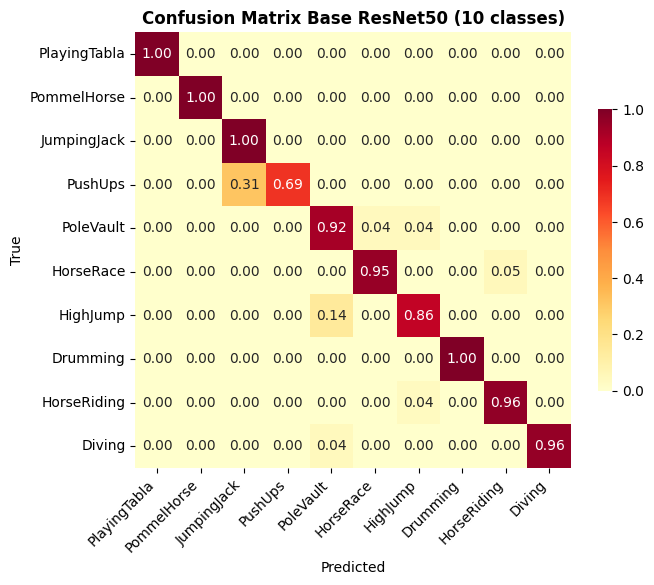

In [ ]:
base_acc, base_preds, base_labels = test_model(teacher, base_test_loader, device)
plot_confusion_matrix(base_labels, base_preds, num_classes=n_base,
                      classes_list=cfg.SELECTED_CLASSES, name="Base ResNet50 (10 classes)")

## **Part 2: Continual learning with replay**

Add new classes step by step: 10 to 20 to 30. Keep a small buffer of old clips and mix them into every new batch. Replay was the best method in the continual learning study. Plot the same charts as the CL notebook: training curves, confusion matrix, old vs new accuracy, and the forgetting curve.

In [13]:
# the continual model starts from the base teacher
model = unfreeze_all(teacher).to(device)
forget_hist = []

# buffer of old clips: 15 base clips per class (big enough for base + task 1 later)
buffer = ReplayBuffer(max_size=600)
fill_buffer(buffer, base_train_loader, per_class=15)
print(f"buffer: {len(buffer.data)} clips")

buffer: 150 clips


**Task 1**

Add 10 new classes to the base model. Expand the model to accommodate the new classes and train it on the combined dataset of old and new classes. Evaluate the model's performance on both the old and new classes, and visualize the results using confusion matrices and accuracy plots.

To train the model on the new classes, use a replay strategy. This involves maintaining a small buffer of old clips and mixing them into every new batch during training. This helps the model retain knowledge of previously learned classes while learning new ones.

In [ ]:
model = expand_classifier(model, n_base + n_t1) # Grow the head to 20 classes and learn task 1
model = unfreeze_all(model).to(device)

set_seed(cfg.SEED)
track1 = {"Base": base_test_loader, "Task 1": task1_test_loader}
hist_t1 = train_continual(model, task1_train_loader, task1_val_loader, device,     
                          buffer=buffer, num_old_classes=n_base,
                          epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                          track_loaders=track1, track_history=forget_hist)
torch.cuda.empty_cache()

Epoch [1/5] | Train Acc: 0.7853 Loss: 0.8413 | Val Acc: 0.8693 Loss: 0.6449
Epoch [2/5] | Train Acc: 0.9818 Loss: 0.1450 | Val Acc: 0.8824 Loss: 0.4732
Epoch [3/5] | Train Acc: 0.9936 Loss: 0.0588 | Val Acc: 0.8627 Loss: 0.6051
Epoch [4/5] | Train Acc: 0.9925 Loss: 0.0486 | Val Acc: 0.8431 Loss: 0.5540
Epoch [5/5] | Train Acc: 0.9984 Loss: 0.0274 | Val Acc: 0.8693 Loss: 0.5825


Loss and accuracy curves are plotted to visualize the training process on task 1 using replay method.

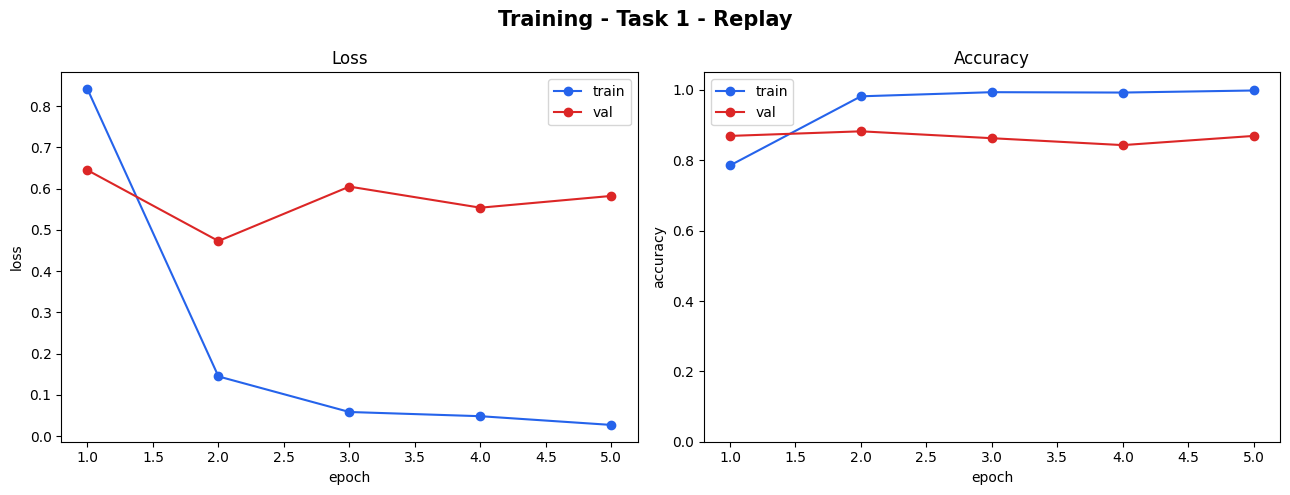

In [15]:
plot_training_results(hist_t1, task_name="Task 1 - Replay")

**Task 2**

Add 10 more new classes to the model. Now the model has been expanded to a total of 30 classes. Train the model and evaluate its performance like in task1 with confusion matrices and accuracy plots.

The buffer is updated with new clips of task1 dataset.

In [16]:
# add task 1 clips to the buffer, then grow to 30 and learn task 2
fill_buffer(buffer, task1_train_loader, per_class=15)
model = expand_classifier(model, n_base + n_t1 + n_t2)
model = unfreeze_all(model).to(device)

set_seed(cfg.SEED)
track2 = {"Base": base_test_loader, "Task 1": task1_test_loader, "Task 2": task2_test_loader}
hist_t2 = train_continual(model, task2_train_loader, task2_val_loader, device,
                          buffer=buffer, num_old_classes=n_base + n_t1,
                          epochs=cfg.CL_EPOCHS, lr=cfg.CL_LR,
                          track_loaders=track2, track_history=forget_hist)
torch.cuda.empty_cache()

Epoch [1/5] | Train Acc: 0.7472 Loss: 1.0560 | Val Acc: 0.8165 Loss: 0.8542
Epoch [2/5] | Train Acc: 0.9707 Loss: 0.2127 | Val Acc: 0.8291 Loss: 0.5147
Epoch [3/5] | Train Acc: 0.9914 Loss: 0.0800 | Val Acc: 0.8418 Loss: 0.5618
Epoch [4/5] | Train Acc: 0.9939 Loss: 0.0574 | Val Acc: 0.8354 Loss: 0.5685
Epoch [5/5] | Train Acc: 0.9980 Loss: 0.0342 | Val Acc: 0.8418 Loss: 0.5866


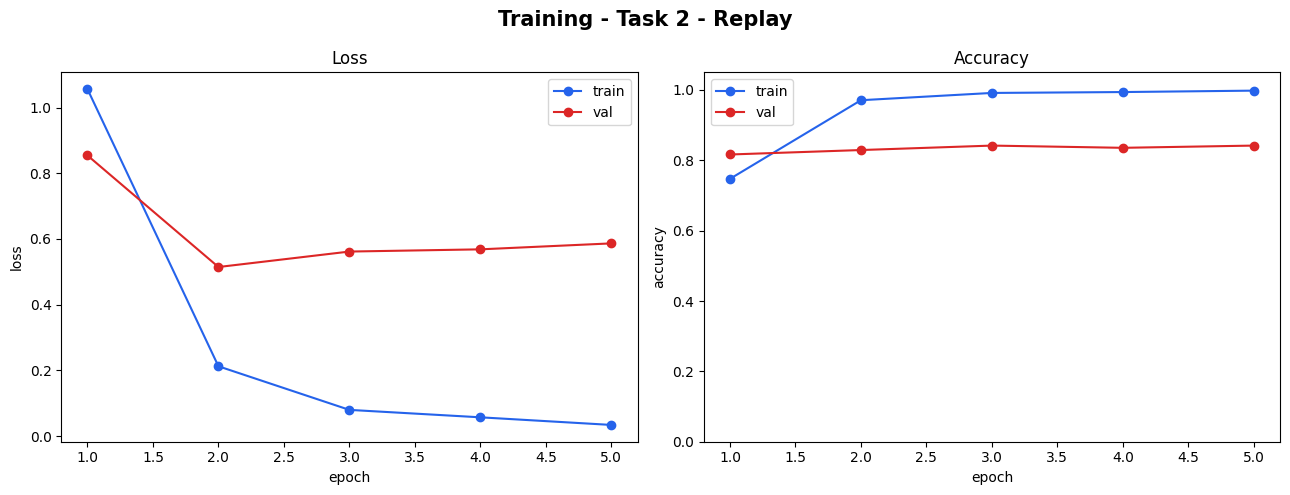

In [17]:
plot_training_results(hist_t2, task_name="Task 2 - Replay")

Test the model on the final combined test set that contains all classes seen. 

Plot the forgetting curve to visualize how the model retains knowledge of previously learned classes while learning new ones.

Test Accuracy: 0.7924


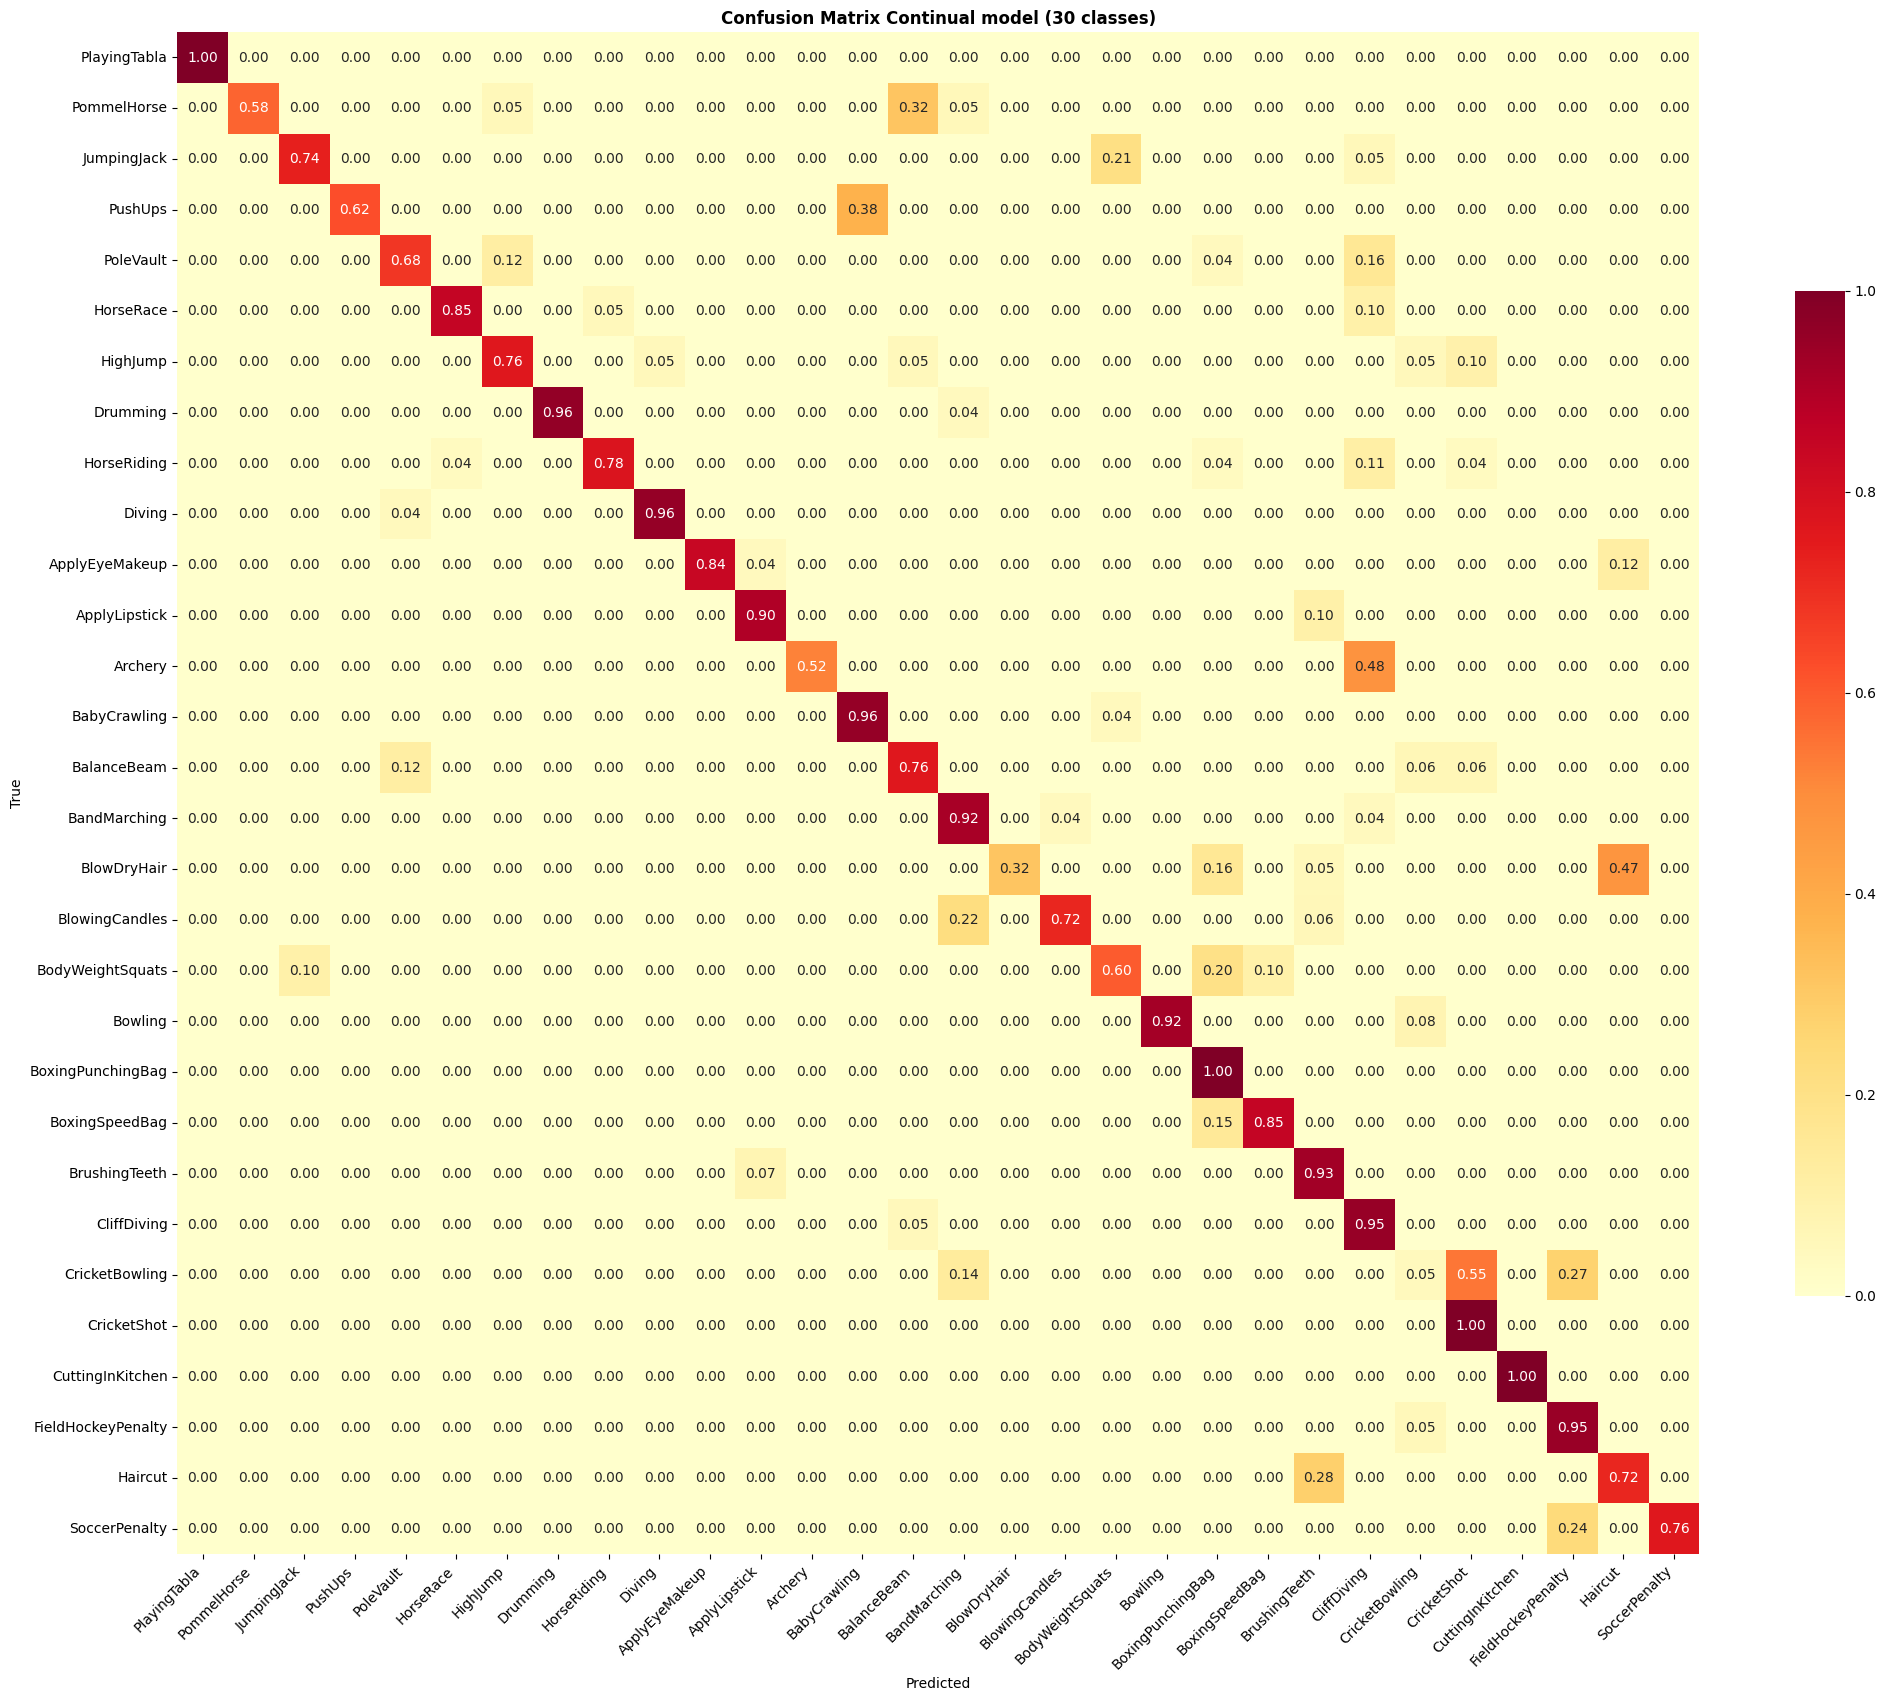

In [18]:
# test the final continual model on all 30 classes
cl_acc, cl_preds, cl_labels = test_model(model, combined_test_loader2, device)
plot_confusion_matrix(cl_labels, cl_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Continual model (30 classes)")

In [19]:
# old vs new accuracy, like the CL notebook
split_at = n_base + n_t1
print_detailed_metrics(cl_labels, cl_preds, num_classes=len(ALL_CLASSES_LIST),
                       classes_list=ALL_CLASSES_LIST,
                       split_old=(0, split_at), split_new=(split_at, len(ALL_CLASSES_LIST)))


METRICS FOR 30 CLASSES
  Accuracy : 0.7924
  F1-Score : 0.7840

PER-CLASS REPORT
                    precision    recall  f1-score   support

      PlayingTabla       1.00      1.00      1.00        17
       PommelHorse       1.00      0.58      0.73        19
       JumpingJack       0.88      0.74      0.80        19
           PushUps       1.00      0.62      0.77        16
         PoleVault       0.85      0.68      0.76        25
         HorseRace       0.94      0.85      0.89        20
          HighJump       0.80      0.76      0.78        21
          Drumming       1.00      0.96      0.98        25
       HorseRiding       0.95      0.78      0.86        27
            Diving       0.96      0.96      0.96        23
    ApplyEyeMakeup       1.00      0.84      0.91        25
     ApplyLipstick       0.86      0.90      0.88        20
           Archery       1.00      0.52      0.68        25
      BabyCrawling       0.79      0.96      0.86        23
       BalanceBea

Visualize the forgetting curve for each task based on accuracy over the whole training process.

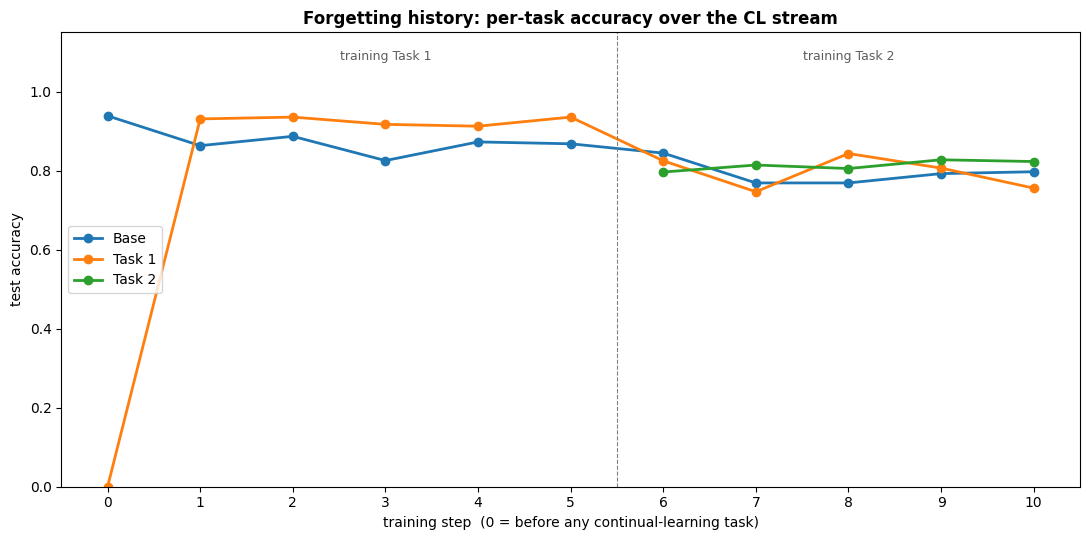

In [ ]:
plot_forgetting_history(forget_hist, epochs_per_task=cfg.CL_EPOCHS)

## **Part 3: Knowledge distillation (cosine)**

Copy the big 30 class continual model into a small MobileNet student. Use cosine distillation, the best method in the distillation study. Plot the training curve and the confusion matrix, like the distillation notebook.

Create a combined dataloader of the previous tasks.

In [ ]:
train_all_loader = DataLoader(ConcatDataset([base_train, task1_train, task2_train]), batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
val_all_loader   = DataLoader(ConcatDataset([base_val,   task1_val,   task2_val]),   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)

Train a student model on all 30 classes at once using knowledge distillation. 

- The teacher model is the previous ResNet50 Model trained on all 30 classes(previous tasks)
- The student model is a smaller MobileNet model that will learn from the teacher model's outputs.

In [22]:
student = MobileNetV3SmallLSTMStudent(num_classes=len(ALL_CLASSES_LIST)).to(device)
set_seed(cfg.SEED)
student, hist_kd = train_student(student, model, train_all_loader, val_all_loader, device,
                                 mode="cosine", T=cfg.KD_T, ce_weight=cfg.KD_CE_WEIGHT,
                                 distill_weight=cfg.KD_DISTILL_WEIGHT,
                                 epochs=cfg.KD_EPOCHS, lr=cfg.KD_LR)
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 142MB/s]


[cosine] epoch 01/15 | Train Acc: 0.2882 | Val Acc: 0.5546
[cosine] epoch 02/15 | Train Acc: 0.5997 | Val Acc: 0.6471
[cosine] epoch 03/15 | Train Acc: 0.7111 | Val Acc: 0.7038
[cosine] epoch 04/15 | Train Acc: 0.7889 | Val Acc: 0.6828
[cosine] epoch 05/15 | Train Acc: 0.8354 | Val Acc: 0.7479
[cosine] epoch 06/15 | Train Acc: 0.8663 | Val Acc: 0.7626
[cosine] epoch 07/15 | Train Acc: 0.9035 | Val Acc: 0.7563
[cosine] epoch 08/15 | Train Acc: 0.9000 | Val Acc: 0.7647
[cosine] epoch 09/15 | Train Acc: 0.9243 | Val Acc: 0.7521
[cosine] epoch 10/15 | Train Acc: 0.9319 | Val Acc: 0.7626
[cosine] epoch 11/15 | Train Acc: 0.9476 | Val Acc: 0.7521
[cosine] epoch 12/15 | Train Acc: 0.9410 | Val Acc: 0.7647
[cosine] epoch 13/15 | Train Acc: 0.9549 | Val Acc: 0.7458
[cosine] epoch 14/15 | Train Acc: 0.9483 | Val Acc: 0.7479
[cosine] epoch 15/15 | Train Acc: 0.9663 | Val Acc: 0.7542
  best [cosine] val 0.7647


Plot the training curve for the student model after training.

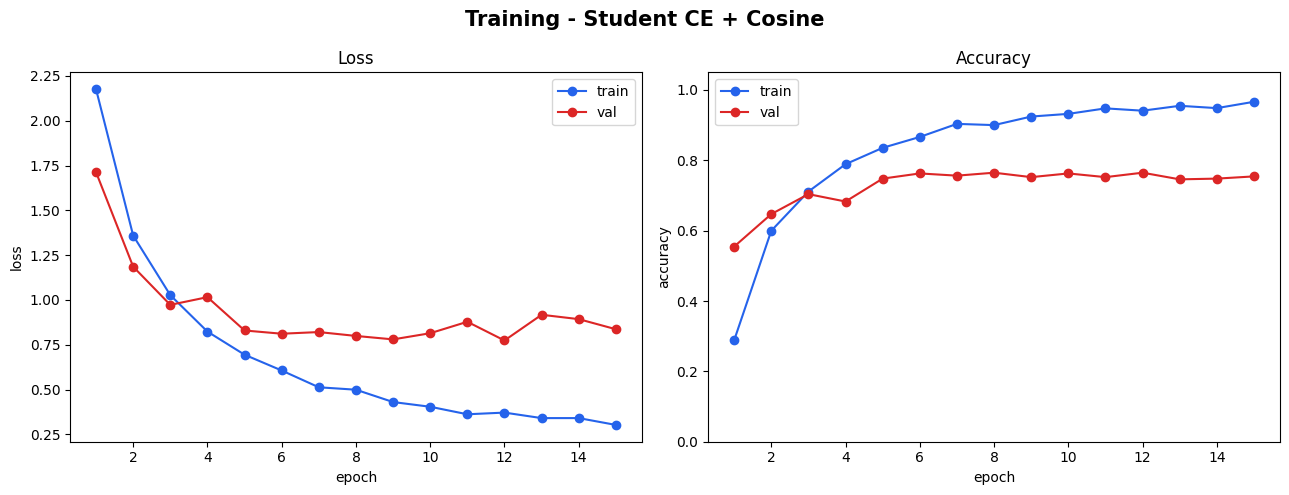

In [23]:
plot_training_results(hist_kd, task_name="Student CE + Cosine")

Plot the confusion matrix for the student model after training.

Test Accuracy: 0.7069


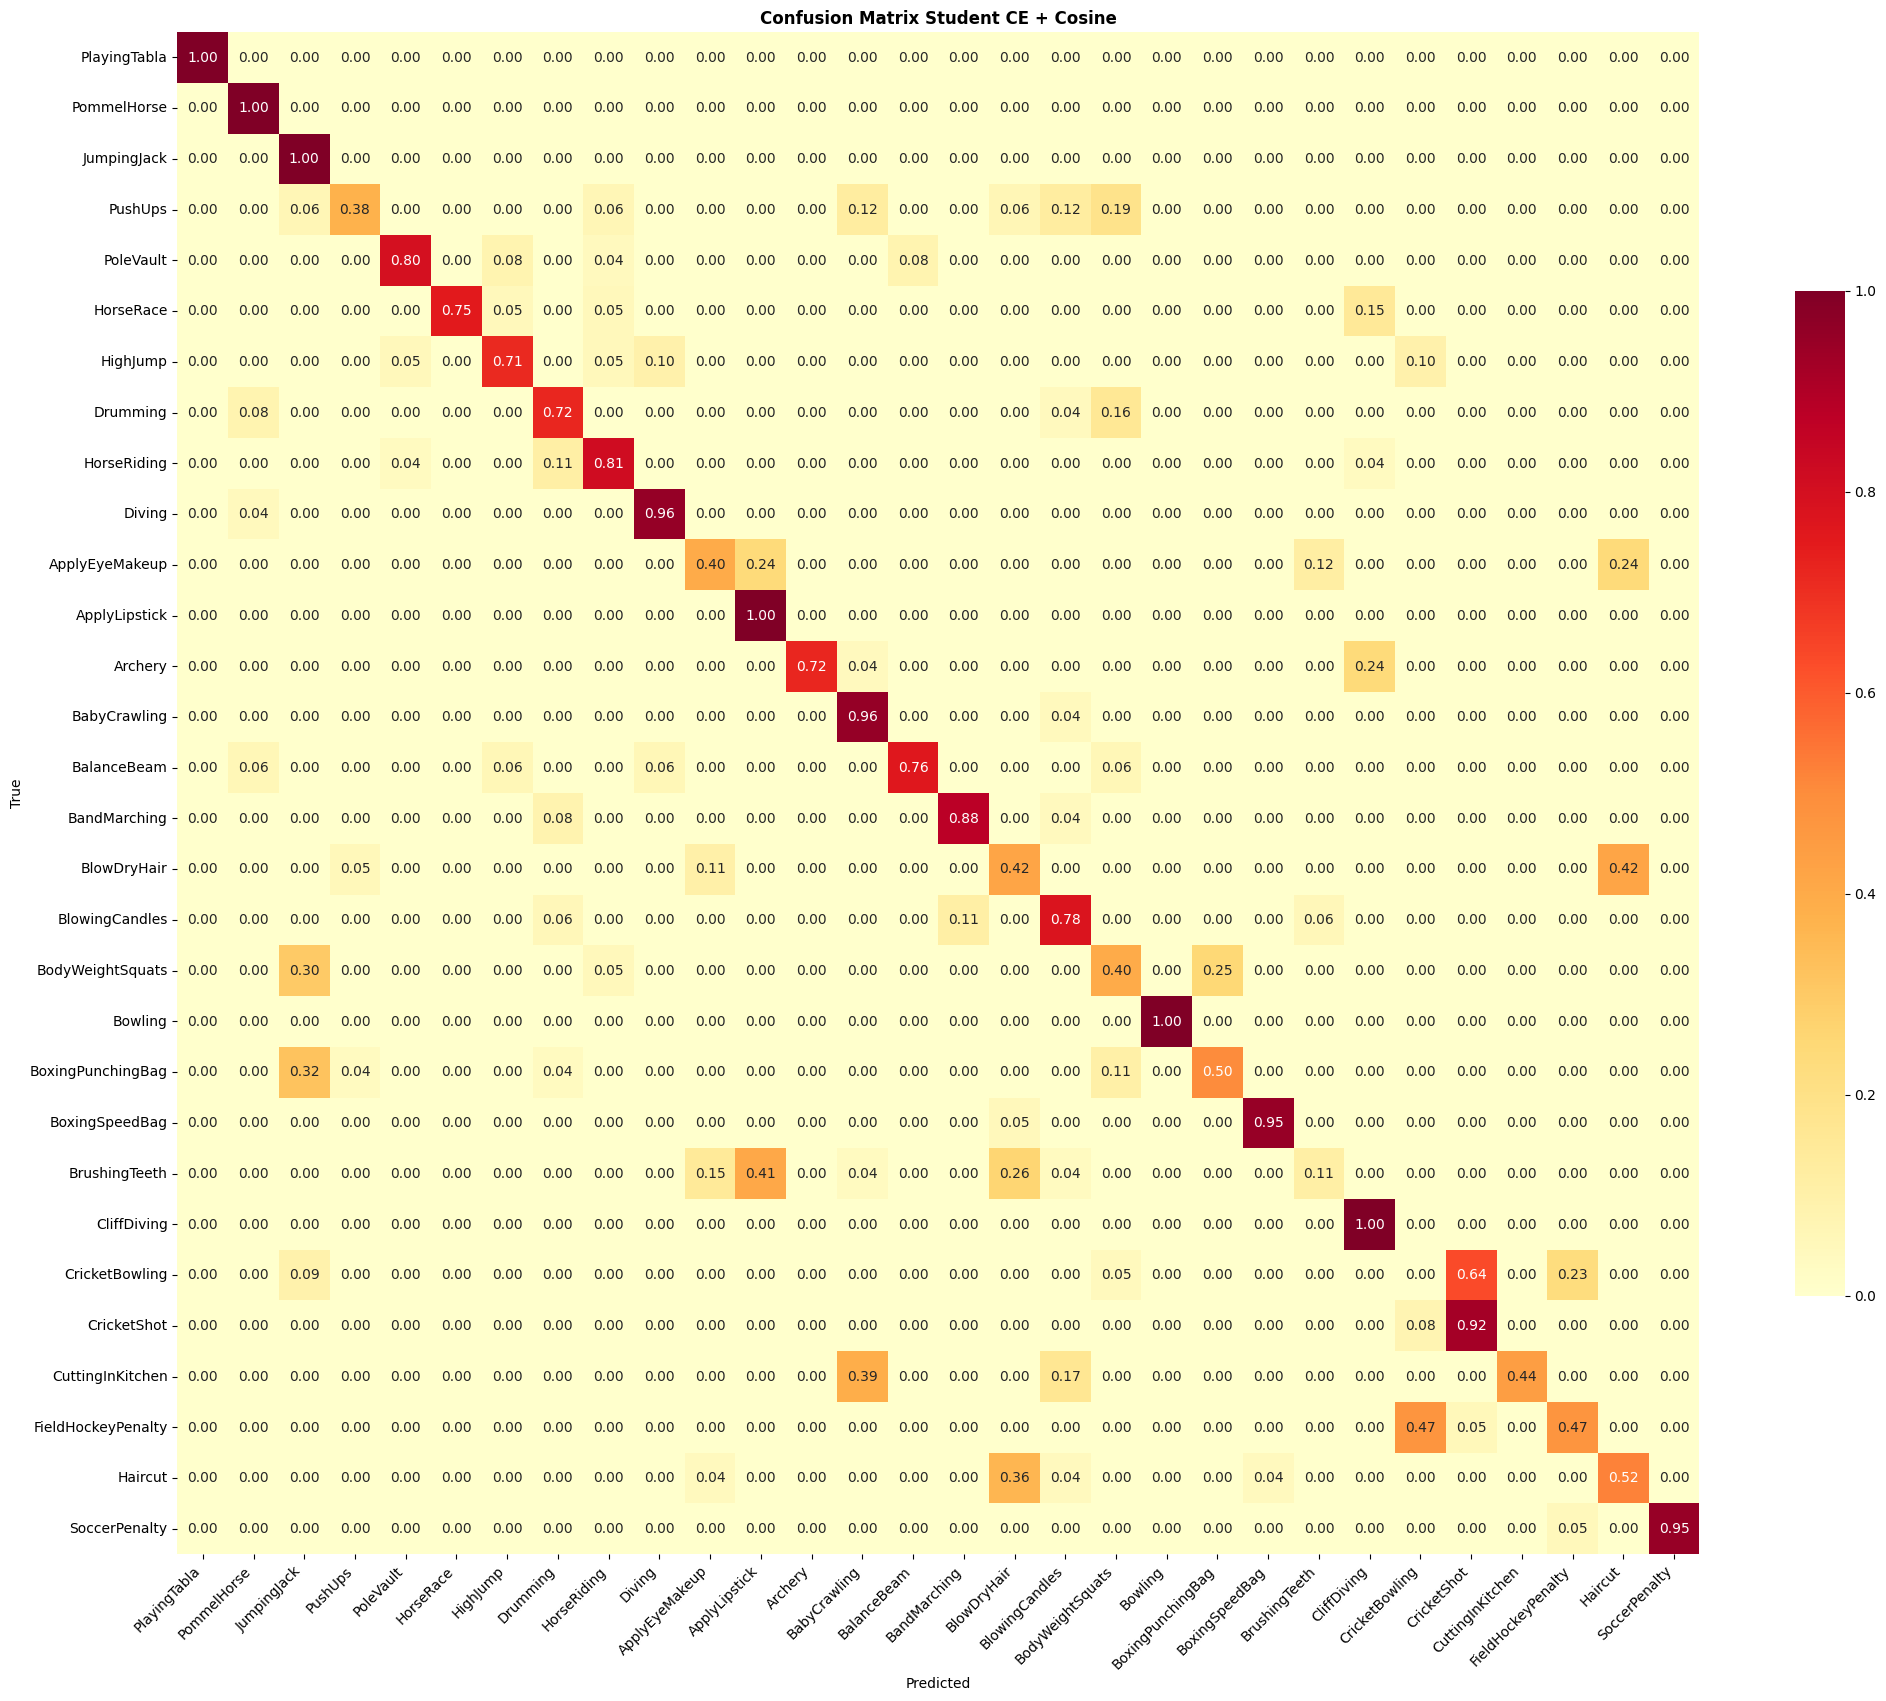

In [24]:
student_acc, student_preds, student_labels = test_model(student, combined_test_loader2, device)
plot_confusion_matrix(student_labels, student_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="Student CE + Cosine")

Compare how many parameters the two models have.

In [25]:
# how much smaller is the student
teacher_params = sum(p.numel() for p in model.parameters())
student_params = sum(p.numel() for p in student.parameters())
print(f"continual model : {cl_acc:.4f}  ({teacher_params/1e6:.1f}M params)")
print(f"student (cosine): {student_acc:.4f}  ({student_params/1e6:.1f}M params, {teacher_params/student_params:.0f}x smaller)")

continual model : 0.7924  (25.9M params)
student (cosine): 0.7069  (1.8M params, 14x smaller)


## **Part 4: Few-shot learning (MAML)**

Teach the small student to learn a new class from only a few clips. Use meta-learning with few-shot learning on some new sports, then re-fit the 30 class head. Same steps and same settings as the MAML study notebook.

Create a few-shot learning setup using Model-Agnostic Meta-Learning (MAML) to enable the small student model to learn new classes from only a few clips. 

In [ ]:
torch.cuda.empty_cache(); gc.collect() # empty the GPU cache and collect garbage to free up memory for meta-learning

# same settings as the MAML study notebook
N_WAY = 5; K_SHOT = 3; K_QUERY = 3
META_EPOCHS = 8; META_EPISODES = 60
INNER_STEPS = 5; META_INNER_LR = 0.05; META_LR = 1e-4
META_TRAIN_LAST = 4
HEAD_RECAL_EPOCHS = 3; HEAD_RECAL_LR = 1e-3
POOL_PER_CLASS = 6

# novel sports for meta-training (not among the 30 known classes)
known     = set(ALL_CLASSES_LIST)
MAML_META = [c for c in cfg.SPORTS_META if c not in known][:15]
maml_c2i  = {c: i for i, c in enumerate(ALL_CLASSES_LIST + MAML_META)}

ULAL_META_ROOT = f"{cfg.DATA_ROOT}/grouped_ulal_meta"
meta_split = build_group_split(MAML_META, train_groups=18, val_groups=3)
preprocess_group_split(meta_split, MAML_META, output_root=ULAL_META_ROOT, max_samples=8, max_test_samples=6)
meta_train_ds = UCF101Clips(os.path.join(ULAL_META_ROOT, "train"), class_to_idx=maml_c2i)
pool_clips, pool_labels = build_pool([meta_train_ds], per_class=POOL_PER_CLASS)
meta_ids = sorted(set(pool_labels.tolist()))
print(f"meta classes {len(MAML_META)} | pool {tuple(pool_clips.shape)}")


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_ulal_meta
Classes: 15 | Train limit: 8

Processing split: train



Processing split: val



Processing split: test



Done. Clips ready at: /content/UCF101/grouped_ulal_meta
meta classes 15 | pool (90, 16, 3, 224, 224)


Create a new model for the few-shot learning task. Use the MAML algorithm to train the model on a set of tasks, allowing it to learn how to adapt quickly to new tasks with limited data. After meta-training, recalibrate the model's head to restore the 30-way classification capability.

/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1169: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


[maml] epoch 1/8 | meta query acc 0.9367
[maml] epoch 2/8 | meta query acc 0.9656
[maml] epoch 3/8 | meta query acc 0.9778
[maml] epoch 4/8 | meta query acc 0.9733
[maml] epoch 5/8 | meta query acc 0.9878
[maml] epoch 6/8 | meta query acc 0.9833
[maml] epoch 7/8 | meta query acc 0.9878
[maml] epoch 8/8 | meta query acc 0.9856


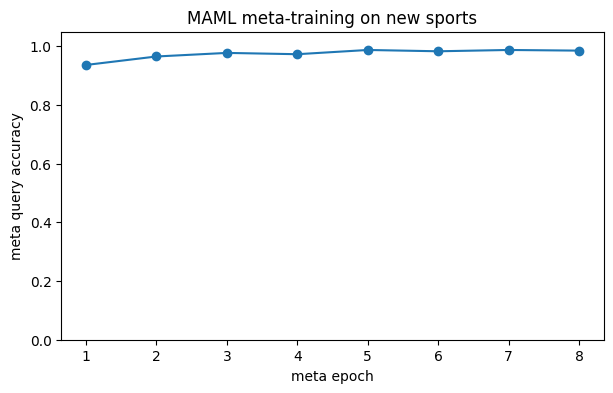

In [ ]:
set_seed(cfg.SEED)
maml_student = copy.deepcopy(student)
maml_student.fc = nn.Linear(cfg.HIDDEN_SIZE, N_WAY).to(device)   # throwaway 5-way head for episodes

# meta-train only the last blocks (keep base features), then re-fit the 30-way head
maml_student, hist_maml = meta_train_maml(maml_student, pool_clips, pool_labels, meta_ids,
                                          N_WAY, K_SHOT, K_QUERY, META_EPOCHS, META_EPISODES,
                                          META_INNER_LR, INNER_STEPS, META_LR, device,
                                          freeze_backbone=True, train_last=META_TRAIN_LAST)
maml_student = recalibrate_head(maml_student, train_all_loader, len(ALL_CLASSES_LIST), device,
                                HEAD_RECAL_EPOCHS, HEAD_RECAL_LR)   # Head recalibration after meta-learning to restore the 30-way head
del pool_clips, pool_labels; gc.collect(); torch.cuda.empty_cache()

plt.figure(figsize=(7, 4))
plt.plot(range(1, META_EPOCHS + 1), hist_maml["query_accs"], marker="o")
plt.xlabel("meta epoch"); plt.ylabel("meta query accuracy"); plt.ylim(0, 1.05)
plt.title("MAML meta-training on new sports")
plt.show()

Plot the confusion matrix after meta-learning and head recalibration. Plot on old dataset to see if the model still remembers the previous classes.

Test Accuracy: 0.6779
MAML student on 30 classes: 0.6779  (KD student was 0.7069)


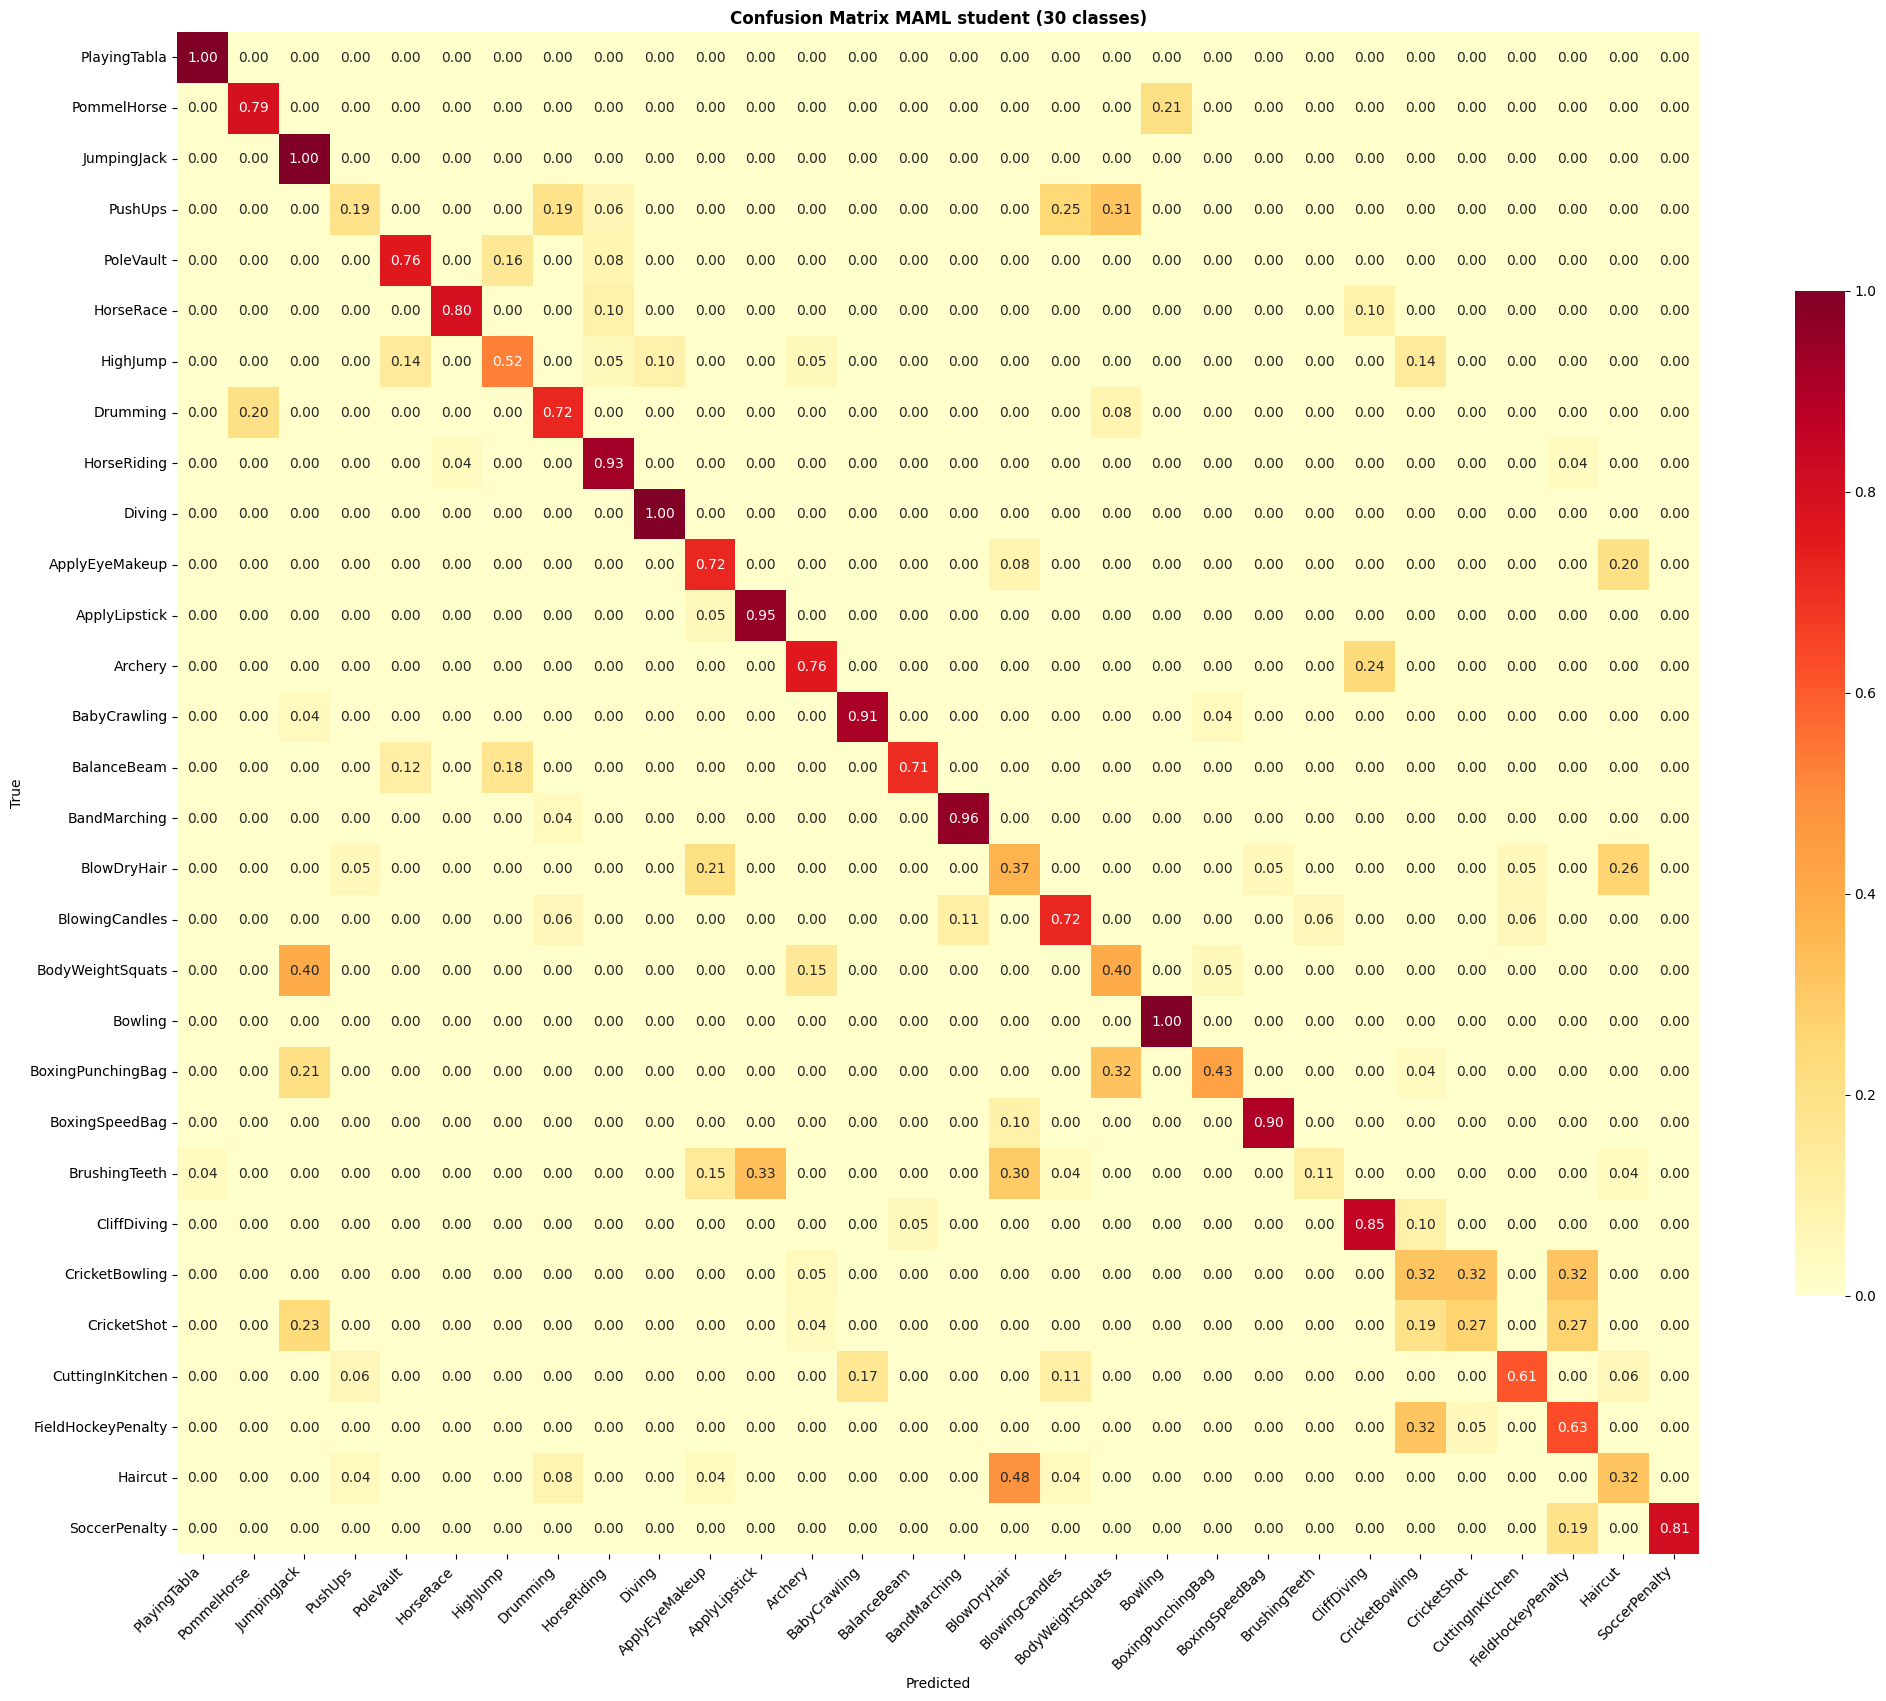

In [28]:
# test the MAML student on the 30 known classes, like the MAML notebook
maml_acc, maml_preds, maml_labels = test_model(maml_student, combined_test_loader2, device)
print(f"MAML student on 30 classes: {maml_acc:.4f}  (KD student was {student_acc:.4f})")
plot_confusion_matrix(maml_labels, maml_preds, num_classes=len(ALL_CLASSES_LIST),
                      classes_list=ALL_CLASSES_LIST, name="MAML student (30 classes)")
torch.cuda.empty_cache()

## **Part 5: Test on real YouTube videos**

Test on real short videos from YouTube. We test the continual teacher (ResNet50) and the small student (MobileNet) on the same clips, then compare them in a table. Use classes the models already know. Put your own short video links below. YouTube can block downloads on Colab, so a local file or an archive.org link is safer.

In [29]:
# short YouTube videos for classes the models know (must be in the 30 classes)
YT_VIDEOS = {
    "PushUps": ["https://www.youtube.com/watch?v=WDIpL0pjun0"],
    "Bowling": ["https://www.youtube.com/shorts/R3XK7QtASAk"],
}
# keep only classes the models know, then download the clips
yt_known_videos = {c: urls for c, urls in YT_VIDEOS.items() if c in class_to_idx}
print(f"testing known classes: {list(yt_known_videos)}")
yt_clips, yt_labels, yt_videos = download_youtube_clips(yt_known_videos, class_to_idx, clips_per_video=20)
print(f"downloaded {len(yt_clips)} clips")
torch.cuda.empty_cache()

testing known classes: ['PushUps', 'Bowling']
  PushUps video 0: 20 clips
  PushUps         : 1 usable video(s)
  Bowling video 0: 20 clips
  Bowling         : 1 usable video(s)
downloaded 40 clips


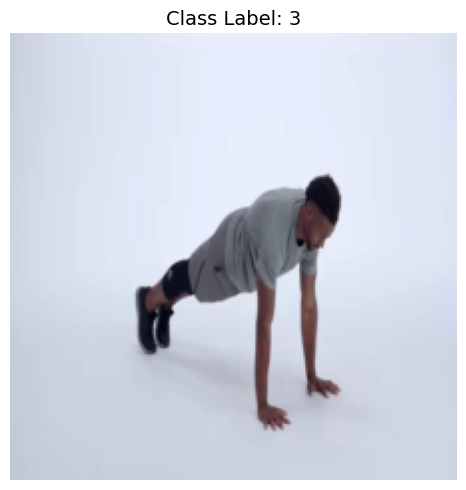

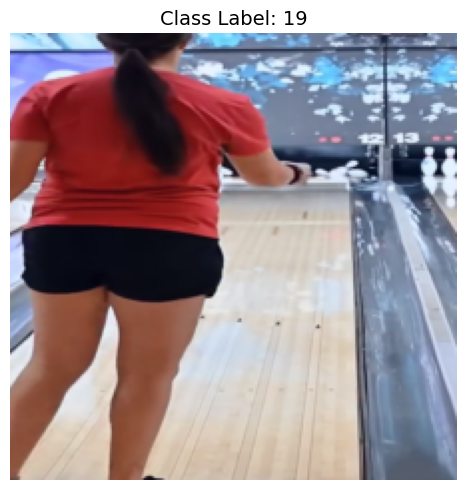

In [30]:
# look at one frame from the first and last clip
UCF101Clips.show_frame(yt_clips, yt_labels, clip_idx=0, frame_idx=0)
UCF101Clips.show_frame(yt_clips, yt_labels, clip_idx=len(yt_clips) - 1, frame_idx=0)

Test both models on the same real clips.

In [ ]:
yt_loader = DataLoader(TensorDataset(yt_clips, yt_labels), batch_size=cfg.BATCH_SIZE)
teacher_yt_acc, _, _ = test_model(model,   yt_loader, device)
student_yt_acc, _, _ = test_model(student, yt_loader, device)
print(f"teacher (ResNet50) on YouTube : {teacher_yt_acc:.3f}")
print(f"student (MobileNet) on YouTube: {student_yt_acc:.3f}")
torch.cuda.empty_cache()

Test Accuracy: 0.2750


Test Accuracy: 0.7500
teacher (ResNet50) on YouTube : 0.275
student (MobileNet) on YouTube: 0.750


Comparison between the teacher and student models on the same real clips.

In [ ]:
yt_rows = [
    {"model": "CL teacher (ResNet50)",  "youtube_acc": round(teacher_yt_acc, 3),
     "ucf_acc": round(cl_acc, 3),      "params_M": round(teacher_params / 1e6, 1)},
    {"model": "KD student (MobileNet)", "youtube_acc": round(student_yt_acc, 3),
     "ucf_acc": round(student_acc, 3), "params_M": round(student_params / 1e6, 1)},
]
yt_df = pd.DataFrame(yt_rows)
print(yt_df.to_string(index=False))

                 model  youtube_acc  ucf_acc  params_M
 CL teacher (ResNet50)        0.275    0.792      25.9
KD student (MobileNet)        0.750    0.707       1.8


## **Summary**

In [33]:
print("ULAL pipeline results")
print(f"  base ResNet50 (10 classes)  : {base_acc:.4f}")
print(f"  replay CL (30 classes)      : {cl_acc:.4f}")
print(f"  MobileNet student (cosine)  : {student_acc:.4f}  ({teacher_params/student_params:.0f}x smaller)")
print(f"  MAML student (30 classes)   : {maml_acc:.4f}")
print(f"  YouTube teacher vs student  : {teacher_yt_acc:.3f} vs {student_yt_acc:.3f}")

ULAL pipeline results
  base ResNet50 (10 classes)  : 0.9387
  replay CL (30 classes)      : 0.7924
  MobileNet student (cosine)  : 0.7069  (14x smaller)
  MAML student (30 classes)   : 0.6779
  YouTube teacher vs student  : 0.275 vs 0.750


Create a .json file with final results.

In [34]:
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
payload = {"base_acc": base_acc, "continual_acc": cl_acc, "student_acc": student_acc,
           "maml_student_acc": maml_acc, "youtube_teacher_acc": teacher_yt_acc,
           "youtube_student_acc": student_yt_acc,
           "teacher_params": teacher_params, "student_params": student_params,
           "maml_curve": hist_maml["query_accs"]}
with open(f"{cfg.RESULTS_DIR}/ulal_summary.json", "w") as f:
    json.dump(payload, f, indent=2)
print(f"saved -> {cfg.RESULTS_DIR}/ulal_summary.json")

saved -> /content/drive/MyDrive/apai/results/ulal_summary.json
